In [91]:
#Importing Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

In [93]:
df = pd.read_csv('cyberbullying_tweets.csv')

In [94]:
df.head() 

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [26]:
df['cyberbullying_type'].unique()

array(['not_cyberbullying', 'gender', 'religion', 'other_cyberbullying',
       'age', 'ethnicity'], dtype=object)

In [27]:
#Given that the "other_cyberbullying" class is too broad, encompassing multiple categories
#and negatively impacting the accuracy of upcoming prediction models, I have decided to exclude
#it and focus on the remaining classes.

df = df[df["cyberbullying_type"] != "other_cyberbullying"]
df['cyberbullying_type'].unique()

array(['not_cyberbullying', 'gender', 'religion', 'age', 'ethnicity'],
      dtype=object)

The output belongs to 6 different classes

In [29]:
#Checking for Null
df.isnull().sum()

tweet_text            0
cyberbullying_type    0
dtype: int64

In [30]:
#Checking if the outputs are balance
df['cyberbullying_type'].value_counts()

cyberbullying_type
religion             7998
age                  7992
gender               7973
ethnicity            7961
not_cyberbullying    7945
Name: count, dtype: int64

The outputs are pretty balance so doesnt have to oversample or undersample

In [32]:
#Checking for duplicates
df['tweet_text'].duplicated().sum()

95

In [41]:
#Dropping the Duplicates
df.drop_duplicates('tweet_text',inplace=True,ignore_index=True)
df['tweet_text'].duplicated().sum()

0

In [43]:
#LABEL ENCODING THE cyberbullying_type (because machine learning model arent good with categorical data) 
df['cyberbullying_type'] = df['cyberbullying_type'].replace({'not_cyberbullying':0,'gender':1,'religion':2,'age':3,'ethnicity':4})

C:\Users\moham\AppData\Local\Temp\ipykernel_7296\53205001.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['cyberbullying_type'] = df['cyberbullying_type'].replace({'not_cyberbullying':0,'gender':1,'religion':2,'age':3,'ethnicity':4})


In [45]:
import nltk
nltk.download('stopwords')
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [46]:
#STOP WORDS
from nltk.corpus import stopwords
stop_words_list = stopwords.words('english')
additional_stop_words = ['rt', 'mkr', 'didn', 'bc', 'n', 'm', 'im', 'll', 'y', 've', 'u', 'ur', 'don', 't', 's']
stop_words_list.extend(additional_stop_words)
#PorterStemmer for Stemming
from nltk.stem import PorterStemmer,WordNetLemmatizer

stemming = PorterStemmer()
lem = WordNetLemmatizer()

In [49]:
#Text Preprocessing
#Remove spaces,special characters(@,#,http,etc),lower,split,remove_stopwords,Stemming


def remove_usernames(tweet):
    return re.sub(r'@\w+', '', tweet).strip()


def remove_hashtags(tweet):
    words = tweet.strip().split()
    words = [word for word in words if word[0] != '#']
    return ' '.join(words)


def remove_links(tweet):
    http_pos = tweet.find('http')
    if http_pos != -1:
        tweet = tweet[:http_pos]
    return tweet.strip()



corpus =[] #This Corpus will have cleaned sentences

for i in range(0,len(df)):
    updated = df['tweet_text'][i]
    updated = re.sub(':',' ',updated)
    updated = re.sub(r'(http\S+|[@#]\w+)|[^a-zA-Z0-9\s]', lambda x: x.group(1) if x.group(1) else ' ', updated)
   
    updated = remove_usernames(updated)

    updated = remove_hashtags(updated)
    updated = remove_links(updated)
    updated = updated.lower()
    updated = updated.split()
    
    updated = [lem.lemmatize(words,pos= 'v') for words in updated if words not in stop_words_list]
    updated = ' '.join(updated)
    corpus.append(updated)
        

In [50]:
#CHECKING if I did all the Preprocessing Correctly
print('Orginal Sentence: ' ,df['tweet_text'][1978])
print('Preprocesed Sentence: ',corpus[1978])

Orginal Sentence:  played the song 'Another face in the Crowd' by Clockwork Bully on @myspace http://t.co/j7bHeDp
Preprocesed Sentence:  play song another face crowd clockwork bully


In [51]:
#We will Remove the outliers in the dataset
index_to_keep = []
for i,words in enumerate(corpus):
    z = corpus[i].split()
    if len(z)>3 and len(z)<100:
        index_to_keep.append(i)    

In [52]:
len(index_to_keep)

37038

In [53]:
index_to_keep = [index for index in index_to_keep if index < len(corpus)]

# Filter sentences in the  corpus based on the index list
filtered_corpus = [corpus[index] for index in index_to_keep]

In [54]:
len(filtered_corpus)

37038

In [55]:
filtered_corpus

['classy whore red velvet cupcakes',
 'meh p thank head concern another angry dude twitter',
 'isis account pretend kurdish account like islam lie',
 'yes test god good bad indifferent weird whatever prove gods existence',
 'itu sekolah ya bukan tempat bully ga jauh kaya neraka',
 'karma hope bite kat butt nasty',
 'rebecca black drop school due bully',
 'turkish state kill 241 children last 11 years',
 'love best response hotcakes manage film non committal meh adolescent',
 'parem de fazer bully comigo uhahuah bando de preto',
 'tadinhu de mim sofrendo bull viu mimi',
 'twitter basically angry letter generation',
 'best pick line hi cute love people call jam potter bully mypatronusisyou',
 'gotta walk class officially hate stupid bus system',
 'know saudis chase girls burn build',
 'kid love mohamad bin zayed city',
 'still jack amsterdam ciroc crown bud light lime rita cru love handle feel jiggle walk',
 'men ones go push real change ones power generally need help',
 'wish arena part

Seems to look good

# Converting TEXT TO VECTORS

In [65]:
#BAG OF WORDS
from sklearn.feature_extraction.text import CountVectorizer

In [67]:
cv = CountVectorizer()
x = cv.fit_transform(filtered_corpus).toarray() 

In [69]:
y = df['cyberbullying_type'].iloc[index_to_keep]

In [71]:
#Lets split the model into train Test

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=0)

In [72]:
#Since its a Multiclass Classification I will use Logistic Regression

from sklearn.linear_model import LogisticRegression
model =LogisticRegression()
# Start timer
start_time = time.time()

fit = model.fit(X_train,y_train)

# End timer
end_time = time.time()

In [73]:
# Calculate training time
training_time = end_time - start_time

print(f"Training time of Logistic Regression: {training_time:.6f} seconds")

Training time of Logistic Regression: 65.773333 seconds


In [86]:
y_pred = fit.predict(X_test)

# MODEL EVALUATION METRICS

In [89]:
from sklearn.metrics import accuracy_score
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.9345302375809935


In [83]:
y_pred_train = fit.predict(X_train)
y_pred_test = fit.predict(X_test)

In [85]:
print(' Logistic Regression accuracy on Training set\n\n', classification_report(y_train, y_pred_train))
print(' Logistic Regression accuracy on Testing set\n\n', classification_report(y_test, y_pred_test))

 Logistic Regression accuracy on Training set

               precision    recall  f1-score   support

           0       0.95      0.97      0.96      4914
           1       0.99      0.97      0.98      5924
           2       0.99      0.99      0.99      6310
           3       0.99      1.00      1.00      6265
           4       1.00      1.00      1.00      6217

    accuracy                           0.99     29630
   macro avg       0.98      0.98      0.98     29630
weighted avg       0.99      0.99      0.99     29630

 Logistic Regression accuracy on Testing set

               precision    recall  f1-score   support

           0       0.79      0.86      0.82      1214
           1       0.93      0.88      0.90      1432
           2       0.96      0.96      0.96      1578
           3       0.97      0.98      0.97      1641
           4       0.99      0.98      0.98      1543

    accuracy                           0.93      7408
   macro avg       0.93      0.93   

Text(0.5, 1.0, 'Confusion Matrix')

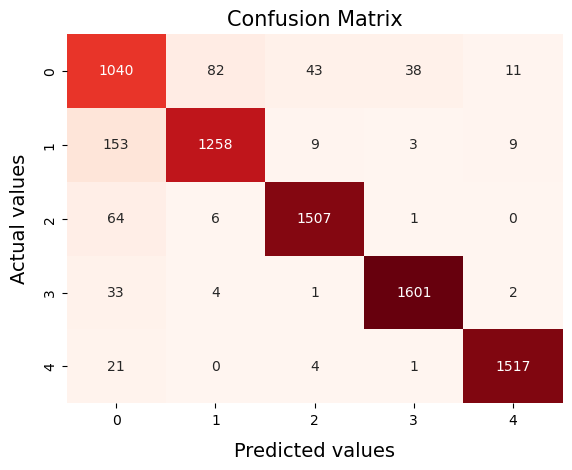

In [87]:
# Confusion Matrix for Logistic Regression
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Reds", fmt='', cbar=False)
plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
plt.ylabel("Actual values", fontdict = {'size':14}, labelpad = 10)
plt.title('Confusion Matrix', size=15)

In [89]:
feature_names = cv.get_feature_names_out()
coefficients = model.coef_[0]
feature_importance = sorted(zip(coefficients, feature_names), key=lambda x: x[0], reverse=True)

In [91]:
top_n = 5
print("Top positive features:\n")
for coef, feature in feature_importance[:top_n]:
    print(f"{feature}: {coef:.4f}")

print("\nTop negative features:\n")
for coef, feature in feature_importance[-top_n:]:
    print(f"{feature}: {coef:.4f}")

Top positive features:

andre: 1.4954
whoa: 1.4889
harassment: 1.4024
tech: 1.3829
quarter: 1.1454

Top negative features:

first: -1.4120
bitch: -1.5456
cunt: -1.6414
terrorism: -1.6818
feminazi: -2.3097


# 2ND MODEL (RANDOM FOREST)

In [95]:
from sklearn.ensemble import RandomForestClassifier

In [97]:
model2 = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)

# Start timer
start_time = time.time()

fit = model2.fit(X_train, y_train)

# End timer
end_time = time.time()

In [98]:
training_time = end_time - start_time

print(f"Training time of Random_forest: {training_time:.6f} seconds")

Training time of Random_forest: 49.111322 seconds


In [99]:
y_pred = fit.predict(X_test)

# EVALUATION METRICS

In [61]:
from sklearn.metrics import accuracy_score
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.9229211663066955


In [62]:
y_pred_train = fit.predict(X_train)
y_pred_test = fit.predict(X_test)

In [63]:
print(' Logistic Regression accuracy on Training set\n\n', classification_report(y_train, y_pred_train))
print(' Logistic Regression accuracy on Testing set\n\n', classification_report(y_test, y_pred_test))

 Logistic Regression accuracy on Training set

               precision    recall  f1-score   support

           0       0.98      1.00      0.99      4914
           1       1.00      0.99      0.99      5924
           2       1.00      1.00      1.00      6310
           3       1.00      1.00      1.00      6265
           4       1.00      1.00      1.00      6217

    accuracy                           1.00     29630
   macro avg       1.00      1.00      1.00     29630
weighted avg       1.00      1.00      1.00     29630

 Logistic Regression accuracy on Testing set

               precision    recall  f1-score   support

           0       0.76      0.85      0.80      1214
           1       0.92      0.85      0.88      1432
           2       0.95      0.95      0.95      1578
           3       0.98      0.97      0.98      1641
           4       0.99      0.96      0.98      1543

    accuracy                           0.92      7408
   macro avg       0.92      0.92   

Text(0.5, 1.0, 'Confusion Matrix')

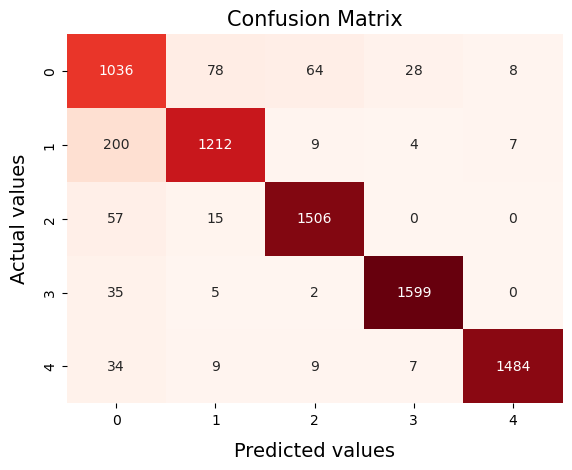

In [64]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Reds", fmt='', cbar=False)
plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
plt.ylabel("Actual values", fontdict = {'size':14}, labelpad = 10)
plt.title('Confusion Matrix', size=15)

In [42]:
text = ['bully stupid victim punch feel and kill them I love fucking with them niggerssssssssss']
new_text  = cv.transform(text)
z = fit.predict(new_text)

if z==0:
    print('NoT Bullying')
elif z==1:
    print('Sexism')
elif z==2:
    print("Religion HAte")
elif z==3:
    print("Other TYpe of CYberbullying")
elif z==4:
    print("AGE BULLYING")
else:
    print('Racist')

NoT Bullying


# NEW DATASET

In [13]:
df = pd.read_csv('FinalBalancedDataset.csv')

In [14]:
df.head()

,Unnamed: 0,Toxicity,tweet
0,0,0,@user when a father is dysfunctional and is s...
1,1,0,@user @user thanks for #lyft credit i can't us...
2,2,0,bihday your majesty
3,3,0,#model i love u take with u all the time in ...
4,4,0,factsguide: society now #motivation


In [15]:
df= df.drop('Unnamed: 0',axis = 1)

In [16]:
df.head()

,Toxicity,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [17]:
df['Toxicity'].value_counts()

0    32592
1    24153
Name: Toxicity, dtype: int64

In [18]:
df.shape

(56745, 2)

In [19]:
#dropping the Duplicates
df.drop_duplicates('tweet',inplace=True,ignore_index=True)

In [20]:
df.shape

(54313, 2)

In [21]:
new_corpus = []



for i in range(0,len(df)):
    updated = df['tweet'][i]
    updated = re.sub(':',' ',updated)
    updated = re.sub(r'(http\S+|[@]\w+)|[^a-zA-Z0-9\s]', lambda x: x.group(1) if x.group(1) else ' ', updated)
   
    updated = remove_usernames(updated)

    updated = remove_hashtags(updated)
    updated = remove_links(updated)
    updated = updated.lower()
    updated = updated.split()
    
    updated = [lem.lemmatize(words,pos= 'v') for words in updated if words not in stop_words_list]
    updated = ' '.join(updated)
    new_corpus.append(updated)

In [22]:
len(new_corpus)

54313

In [23]:
new_corpus[12]

'get see daddy today 80days gettingfed'

In [24]:
#CHECKING if I did all the Preprocessing Correctly
print('Orginal Sentence: ' ,df['tweet'][3])
print('Preprocesed Sentence: ',new_corpus[3])

Orginal Sentence:  #model   i love u take with u all the time in urð±!!! ððððð¦ð¦ð¦  
Preprocesed Sentence:  model love take time


In [25]:
index_to_keep = []
for i,words in enumerate(new_corpus):
    z = new_corpus[i].split()
    if len(z)>3 and len(z)<100:
        index_to_keep.append(i)    

In [26]:
len(index_to_keep)

47686

In [27]:
index_to_keep = [index for index in index_to_keep if index < len(new_corpus)]

# Filter sentences in the  corpus based on the index list
filtered_corpus = [new_corpus[index] for index in index_to_keep]

In [28]:
filtered_corpus

['father dysfunctional selfish drag kid dysfunction run',
 'thank lyft credit use cause offer wheelchair vans pdx disapointed getthanked',
 'model love take time',
 '2 2 huge fan fare big talk leave chaos pay dispute get allshowandnogo',
 'next school year year exams think school exams hate imagine actorslife revolutionschool girl',
 'love land allin cavs champion cleveland clevelandcavaliers',
 'ireland consumer price index mom climb previous 0 2 0 5 may blog silver gold forex',
 'selfish orlando standwithorlando pulseshooting orlandoshooting biggerproblems selfish heabreaking value love',
 'get see daddy today 80days gettingfed',
 'cnn call michigan middle school build wall chant tcot',
 'comment australia opkillingbay seashepherd helpcovedolphins thecove helpcovedolphins',
 'ouch junior angry got7 junior yugyoem omg',
 'thankful paner thankful positive',
 'friday smile around via ig user cookies make people',
 'know essential oil make chemicals',
 'euro2016 people blame ha concede g

In [29]:
from sklearn.feature_extraction.text import CountVectorizer

In [30]:
cv1 = CountVectorizer()
x  = cv1.fit_transform(filtered_corpus).toarray()

In [31]:
df['Toxicity'][2]

0

In [32]:
y = [df['Toxicity'][i] for i in index_to_keep]

In [33]:
y[0]

0

In [34]:
y = df['Toxicity'].iloc[index_to_keep]

In [35]:
y.shape

(47686,)

In [36]:
y.value_counts()

0    27189
1    20497
Name: Toxicity, dtype: int64

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size= 0.20,random_state=42)

In [41]:
from sklearn.linear_model import LogisticRegression
model =LogisticRegression()
# Start timer
start_time = time.time()

fit = model.fit(X_train,y_train)

# End timer
end_time = time.time()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [43]:
training_time = end_time - start_time

print(f"Training time of Logistic Regression: {training_time:.6f} seconds")

Training time of Logistic Regression: 609.123368 seconds


In [44]:
y_pred = fit.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.9398196686936464


In [46]:
y_pred_train = fit.predict(X_train)
y_pred_test = fit.predict(X_test)

In [47]:
print(' Logistic Regression accuracy on Training set\n\n', classification_report(y_train, y_pred_train))
print(' Logistic Regression accuracy on Testing set\n\n', classification_report(y_test, y_pred_test))

 Logistic Regression accuracy on Training set

               precision    recall  f1-score   support

           0       0.97      0.99      0.98     21762
           1       0.99      0.96      0.97     16386

    accuracy                           0.98     38148
   macro avg       0.98      0.98      0.98     38148
weighted avg       0.98      0.98      0.98     38148

 Logistic Regression accuracy on Testing set

               precision    recall  f1-score   support

           0       0.93      0.97      0.95      5427
           1       0.96      0.90      0.93      4111

    accuracy                           0.94      9538
   macro avg       0.94      0.94      0.94      9538
weighted avg       0.94      0.94      0.94      9538



Text(0.5, 1.0, 'Confusion Matrix')

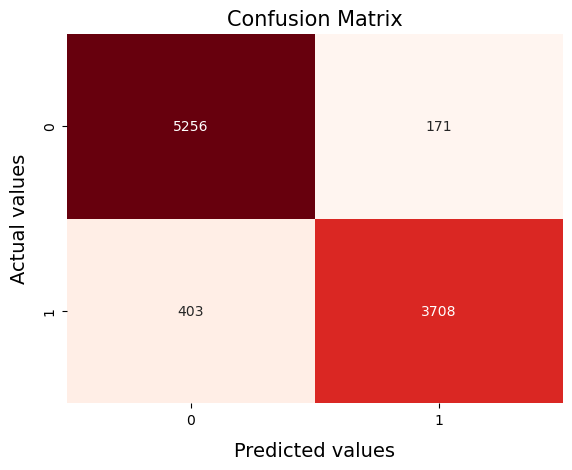

In [48]:
# Confusion Matrix for Logistic Regression
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Reds", fmt='', cbar=False)
plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
plt.ylabel("Actual values", fontdict = {'size':14}, labelpad = 10)
plt.title('Confusion Matrix', size=15)

In [50]:
feature_names = cv1.get_feature_names_out()
coefficients = model.coef_[0]
feature_importance = sorted(zip(coefficients, feature_names), key=lambda x: x[0], reverse=True)

In [53]:
top_n = 10
print("Top negative features:\n")
for coef, feature in feature_importance[:top_n]:
    print(f"{feature}: {coef:.4f}")

print("\nTop positive features:\n")
for coef, feature in feature_importance[-top_n:]:
    print(f"{feature}: {coef:.4f}")

Top negative features:

bitch: 6.8858
hoe: 6.5817
faggot: 5.7202
pussy: 5.5086
retard: 5.3124
niggah: 5.0539
fag: 5.0510
cunt: 4.9023
nigger: 4.7648
nig: 4.3209

Top positive features:

webcammodel: -1.5273
forward: -1.5280
happiness: -1.5652
webcam: -1.6565
wild: -1.7575
sta: -1.7725
hardcore: -2.1198
barcelona: -2.2119
orlando: -2.2995
bihday: -2.5397


In [54]:
from sklearn.ensemble import RandomForestClassifier

In [55]:
model2 = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)

# Start timer
start_time = time.time()

fit = model2.fit(X_train, y_train)

# End timer
end_time = time.time()

In [56]:
training_time = end_time - start_time

print(f"Training time of Random_forest: {training_time:.6f} seconds")

Training time of Random_forest: 180.509712 seconds


In [57]:
y_pred= fit.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.9216816942755295


In [59]:
y_pred_train = fit.predict(X_train)
y_pred_test = fit.predict(X_test)

In [60]:
print(' Logistic Regression accuracy on Training set\n\n', classification_report(y_train, y_pred_train))
print(' Logistic Regression accuracy on Testing set\n\n', classification_report(y_test, y_pred_test))

 Logistic Regression accuracy on Training set

               precision    recall  f1-score   support

           0       0.99      1.00      1.00     21762
           1       1.00      0.99      0.99     16386

    accuracy                           0.99     38148
   macro avg       1.00      0.99      0.99     38148
weighted avg       0.99      0.99      0.99     38148

 Logistic Regression accuracy on Testing set

               precision    recall  f1-score   support

           0       0.91      0.96      0.93      5427
           1       0.94      0.88      0.91      4111

    accuracy                           0.92      9538
   macro avg       0.92      0.92      0.92      9538
weighted avg       0.92      0.92      0.92      9538



Text(0.5, 1.0, 'Confusion Matrix')

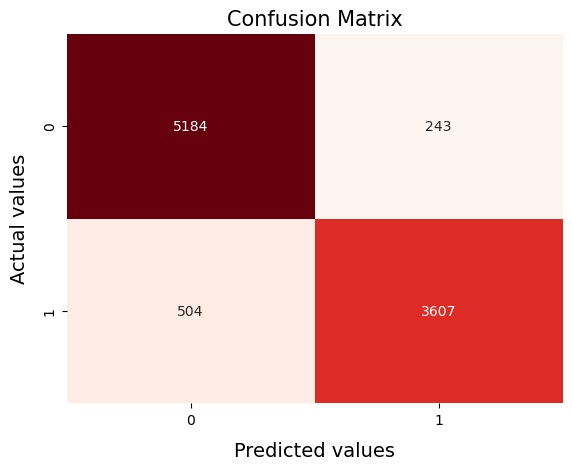

In [61]:
# Confusion Matrix for Logistic Regression
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Reds", fmt='', cbar=False)
plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
plt.ylabel("Actual values", fontdict = {'size':14}, labelpad = 10)
plt.title('Confusion Matrix', size=15)

In [65]:
top_n = 5
print("Top negative features:\n")
for coef, feature in feature_importance[:top_n]:
    print(f"{feature}: {coef:.4f}")

print("\nTop positive features:\n")
for coef, feature in feature_importance[-top_n:]:
    print(f"{feature}: {coef:.4f}")

Top negative features:

bitch: 6.8858
hoe: 6.5817
faggot: 5.7202
pussy: 5.5086
retard: 5.3124

Top positive features:

sta: -1.7725
hardcore: -2.1198
barcelona: -2.2119
orlando: -2.2995
bihday: -2.5397
